# Task 4_ ROI Extraction

- **Mục tiêu:** Hợp nhất candidate từ Task 2 (union HSV+MSER+Canny-Hull) và Task 3 (shape: Hough Circle + Polygon triangle/rectangle), cắt vùng ảnh (ROI) tương ứng từ ảnh đã tiền xử lý ở Task 1, chuẩn hoá kích thước cố định, và gán nhãn theo GT để tạo tập dữ liệu huấn luyện cho Task 6 (HOG) và Task 7 (SVM).

- Lý do cần hợp nhất là vì Task 2 bắt biển theo màu/kết cấu/cạnh, Task 3 bắt thêm biển theo đúng hình dạng thật (kể cả biển nền trắng/đen mà Task 2 bỏ sót vì bão hoà màu thấp). Hợp nhất rồi khử trùng theo IoU trước khi cắt ROI, để 1 vị trí biển thật không bị cắt lặp lại thành nhiều ROI gần giống nhau.

- **Input**:
  - Ảnh màu đã tiền xử lý (Task 1: Median Blur + Dynamic CLAHE)
  - Candidate box từ Task 2
  - Candidate box từ Task 3 
  - GT box (dùng để gán nhãn positive/negative và đo recall/precision)

- **Output**:
  - Ảnh ROI đã crop + resize cố định (64×64).
  - `roi_manifest.json`: Nhãn lớp (hoặc -1 nếu nền/nhiễu), IoU với GT, tập train/val.

- **Quy trình thực hiện:**
   1. Với mỗi ảnh, hợp nhất candidate Task 2 + Task 3, khử trùng bằng NMS theo IoU (ưu tiên nguồn `contour` khi trùng vị trí).
   2. Crop ROI theo `bounding_box` của từng candidate đã hợp nhất.
   3. Lọc ROI theo kích thước tối thiểu (`min_w`, `min_h`) và tỷ lệ khung hợp lý để loại vệt dài/mảnh vỡ nhỏ.
   4. Gán nhãn: ROI có IoU với 1 GT box >= 0.5 (chặt hơn ngưỡng đo recall/precision phía trên) -> *positive* (label = class GT); còn lại -> *negative* (label = -1).
   5. Cân bằng lớp: giữ tối đa `NEG_PER_POS=3` ROI negative cho mỗi 1 ROI positive/ảnh, tránh tập train lệch quá nặng về phía "không phải biển báo".
   6. Chia train/val **theo ảnh gốc** (dùng split có sẵn từ split_dataset/train_files.txt,test_files.txt), không chia theo từng ROI riêng lẻ, để tránh rò rỉ dữ liệu.


# 1. Import thư viện

In [8]:
from pathlib import Path
import sys
import json
import random
import csv
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 2. Thiết lập đường dẫn

In [9]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_config, list_image_paths, get_image_dirs
from src.utils import show_images, read_label_boxes, match_boxes
from src.roi_extraction import extract_rois, resize_roi, draw_rois

CFG, PROJECT_ROOT, CONFIG_PATH = load_config(PROJECT_ROOT)
IMAGE_DIR_RAW, LABEL_DIR = get_image_dirs(CFG, PROJECT_ROOT)

# Đầu vào: ảnh Task 1 + 2 nguồn ứng viên: Task 2 (union HSV+MSER+Canny-Hull) và Task 4b (Hough hình dạng)
PROCESSED_IMAGE_DIR = PROJECT_ROOT / "data" / "processed" / "task1_preprocessing" / "images"
UNION_JSON_DIR       = PROJECT_ROOT / "data" / "processed" / "task2_union_boxes" / "boxes"   
SHAPE_JSON_DIR = PROJECT_ROOT / "data" / "processed" / "task3_shape" / "merged"

# Đầu ra Task 5
OUTPUT_TASK4_DIR   = PROJECT_ROOT / "data" / "processed" / "task4_roi"
ROI_IMG_DIR         = OUTPUT_TASK4_DIR / "images"
ROI_META_DIR        = OUTPUT_TASK4_DIR / "meta"
FIGURE_DIR          = PROJECT_ROOT / "outputs" / "figures" / "task4"

for d in [ROI_IMG_DIR, ROI_META_DIR, FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

assert UNION_JSON_DIR.exists(), f"Không tìm thấy: {UNION_JSON_DIR}. Hãy chạy 02_task2_candidate_boxes.ipynb trước."
if not SHAPE_JSON_DIR.exists():
    print(f"[!] Không tìm thấy {SHAPE_JSON_DIR} — Task 4 vẫn chạy được, "
          f"chỉ dùng ứng viên từ Task 2 union (chưa có circle/triangle/rectangle từ Task 3).")

print(f"PROCESSED_IMAGE_DIR : {PROCESSED_IMAGE_DIR}")
print(f"UNION_JSON_DIR      : {UNION_JSON_DIR}")
print(f"SHAPE_JSON_DIR       : {SHAPE_JSON_DIR}")
print(f"OUTPUT_TASK4_DIR    : {OUTPUT_TASK4_DIR}")

PROCESSED_IMAGE_DIR : c:\Users\lengo\Downloads\Python\Computer Vision\Project\data\processed\task1_preprocessing\images
UNION_JSON_DIR      : c:\Users\lengo\Downloads\Python\Computer Vision\Project\data\processed\task2_union_boxes\boxes
SHAPE_JSON_DIR       : c:\Users\lengo\Downloads\Python\Computer Vision\Project\data\processed\task3_shape\merged
OUTPUT_TASK4_DIR    : c:\Users\lengo\Downloads\Python\Computer Vision\Project\data\processed\task4_roi


## 3. Hợp nhất ứng viên Task 2 (màu/kết cấu) + Task 3 (hình dạng)
Task 2 (union) bắt biển theo màu + đặc trưng vùng + cạnh (HSV + MSER + Canny-Hull),
Task 3 bắt thêm biển theo hình dạng thật (circle qua Hough, triangle/rectangle qua
approxPolyDP), kể cả biển nền trắng/đen mà Task 2 bỏ sót vì bão hoà màu thấp.
Gộp 2 nguồn, loại trùng nếu 1 box Task 3 có IoU cao với 1 box Task 2 (cùng khớp
1 vị trí thật).

In [10]:
NMS_IOU_THRESHOLD = 0.4

In [11]:
from src.roi_extraction import extract_rois, resize_roi, draw_rois, merge_candidates, apply_nms
def load_raw_items(stem):
    union_path = UNION_JSON_DIR / f"{stem}.json"
    union_items = []
    if union_path.exists():
        with open(union_path, "r", encoding="utf-8") as f:
            union_items = json.load(f)

    shape_path = SHAPE_JSON_DIR / f"{stem}.json"
    shape_items = []
    if shape_path.exists():
        with open(shape_path, "r", encoding="utf-8") as f:
            shape_items = json.load(f)

    return union_items, shape_items


def load_merged_items(stem, prioritize_source=True):
    union_items, shape_items = load_raw_items(stem)
    merged = merge_candidates(union_items, shape_items)
    return apply_nms(merged, iou_threshold=NMS_IOU_THRESHOLD, prioritize_source=prioritize_source)


# 4. Tải 5 ảnh mẫu cố định + bounding box ứng viên từ Task 4

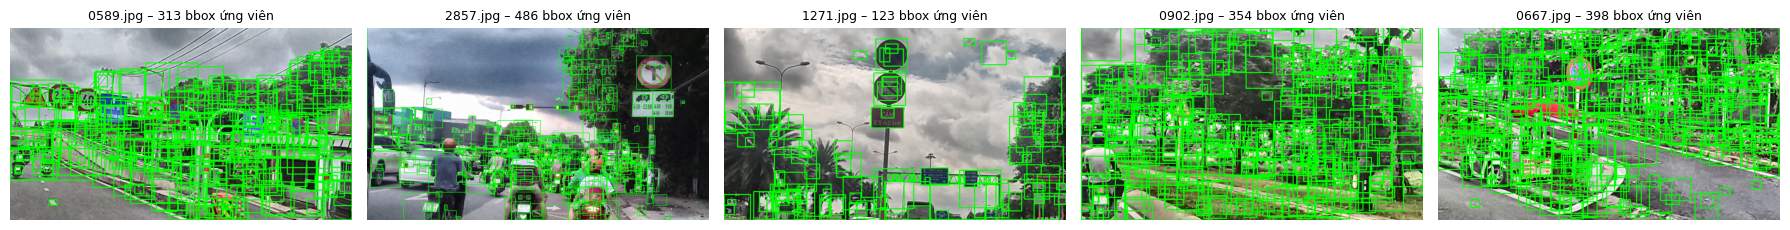

In [12]:
QUALITATIVE_JSON_PATH = PROJECT_ROOT / "data" / "interim" / "qualitative_check_images.json"
assert QUALITATIVE_JSON_PATH.exists(), (
    f"Không tìm thấy {QUALITATIVE_JSON_PATH}. Hãy chạy mục '5 ảnh ngẫu nhiên cố định' "
    f"trong 01_task1_preprocessing.ipynb trước."
)

with open(QUALITATIVE_JSON_PATH, "r", encoding="utf-8") as f:
    sample_names = json.load(f)

survey_img_paths = [PROCESSED_IMAGE_DIR / name for name in sample_names]
for p in survey_img_paths:
    assert p.exists(), f"Không tìm thấy: {p}"

survey_images   = [cv2.imread(str(p)) for p in survey_img_paths]
survey_titles   = [p.name for p in survey_img_paths]
survey_candidates = [load_merged_items(p.stem) for p in survey_img_paths]

bbox_vis = [draw_rois(img, items) for img, items in zip(survey_images, survey_candidates)]
show_images(bbox_vis, [f"{t} – {len(c)} bbox ứng viên" for t, c in zip(survey_titles, survey_candidates)],
            figsize=(18, 5))


# 5. Khảo sát định lượng ngưỡng NMS

## 5.1. Hàm đánh giá tác động của NMS

In [13]:
def evaluate_nms_impact(image_paths, label_dir, iou_threshold):
    total_matched = total_gt = total_before = total_after = n_images = 0
    for path in image_paths:
        img = cv2.imread(str(path))
        if img is None:
            continue
        gt_raw = read_label_boxes(label_dir / f"{path.stem}.txt", img.shape)
        if not gt_raw:
            continue
        n_images += 1
        gt_boxes = [(b["x1"], b["y1"], b["x2"], b["y2"]) for b in gt_raw]

        union_items, shape_items = load_raw_items(path.stem)
        merged = merge_candidates(union_items, shape_items)

        total_before += len(merged)

        nms_items = apply_nms(merged, iou_threshold=iou_threshold)
        total_after += len(nms_items)

        pred_boxes = [(it["bounding_box"][0], it["bounding_box"][1],
                       it["bounding_box"][0] + it["bounding_box"][2],
                       it["bounding_box"][1] + it["bounding_box"][3]) for it in nms_items]
        n_matched, n_gt, _ = match_boxes(pred_boxes, gt_boxes, iou_threshold=0.3)
        total_matched += n_matched
        total_gt += n_gt

    recall = total_matched / total_gt if total_gt else 0.0
    avg_before = total_before / n_images if n_images else 0.0
    avg_after = total_after / n_images if n_images else 0.0
    return {"recall": recall, "avg_before": avg_before, "avg_after": avg_after,
            "reduction": 1 - (avg_after / avg_before) if avg_before else 0.0}


## 5.2. Khảo sát NMS

In [14]:
NMS_CANDIDATES = [0.3, 0.4, 0.5, 0.6, 0.7]

random.seed(42)
all_paths_for_nms = list_image_paths(PROCESSED_IMAGE_DIR)
nms_eval_paths = random.sample(all_paths_for_nms, min(150, len(all_paths_for_nms)))

baseline = evaluate_nms_impact(nms_eval_paths, LABEL_DIR, iou_threshold=1.01)

print(f"{'iou_thr':<8} | {'Recall':<8} | {'Box/ảnh trước':<15} | {'Box/ảnh sau':<13} | {'Giảm %'}")
print(f"{'(gốc)':<8} | {baseline['recall']:<8.4f} | {baseline['avg_before']:<15.2f} | {baseline['avg_before']:<13.2f} | 0.0%")
for thr in NMS_CANDIDATES:
    res = evaluate_nms_impact(nms_eval_paths, LABEL_DIR, thr)
    print(f"{thr:<8} | {res['recall']:<8.4f} | {res['avg_before']:<15.2f} | {res['avg_after']:<13.2f} | {res['reduction']*100:.1f}%")

iou_thr  | Recall   | Box/ảnh trước   | Box/ảnh sau   | Giảm %
(gốc)    | 0.8193   | 475.72          | 475.72        | 0.0%
0.3      | 0.8119   | 475.72          | 286.71        | 39.7%
0.4      | 0.8193   | 475.72          | 347.72        | 26.9%
0.5      | 0.8193   | 475.72          | 392.77        | 17.4%
0.6      | 0.8193   | 475.72          | 430.37        | 9.5%
0.7      | 0.8193   | 475.72          | 450.08        | 5.4%


In [15]:
NMS_IOU_THRESHOLD = 0.4
print(f"NMS_IOU_THRESHOLD = {NMS_IOU_THRESHOLD}")


NMS_IOU_THRESHOLD = 0.4


## 5.3. Kiểm tra quy tắc ưu tiên nguồn khi NMS trùng box

In [16]:
def evaluate_prioritize_source(image_paths, label_dir, iou_threshold, prioritize_source):
    total_matched = total_gt = total_after = n_images = 0
    for path in image_paths:
        img = cv2.imread(str(path))
        if img is None:
            continue
        gt_raw = read_label_boxes(label_dir / f"{path.stem}.txt", img.shape)
        if not gt_raw:
            continue
        n_images += 1
        gt_boxes = [(b["x1"], b["y1"], b["x2"], b["y2"]) for b in gt_raw]

        union_items, shape_items = load_raw_items(path.stem)
        merged = merge_candidates(union_items, shape_items)

        nms_items = apply_nms(merged, iou_threshold=iou_threshold, prioritize_source=prioritize_source)
        total_after += len(nms_items)

        pred_boxes = [(it["bounding_box"][0], it["bounding_box"][1],
                       it["bounding_box"][0] + it["bounding_box"][2],
                       it["bounding_box"][1] + it["bounding_box"][3]) for it in nms_items]
        n_matched, n_gt, _ = match_boxes(pred_boxes, gt_boxes, iou_threshold=0.3)
        total_matched += n_matched
        total_gt += n_gt

    recall = total_matched / total_gt if total_gt else 0.0
    avg_after = total_after / n_images if n_images else 0.0
    return {"recall": recall, "avg_after": avg_after}

res_true = evaluate_prioritize_source(nms_eval_paths, LABEL_DIR, NMS_IOU_THRESHOLD, prioritize_source=True)
res_false = evaluate_prioritize_source(nms_eval_paths, LABEL_DIR, NMS_IOU_THRESHOLD, prioritize_source=False)

print(f"{'prioritize_source':<20} | {'Recall':<8} | {'Box/ảnh sau NMS'}")
print(f"{'True (hiện tại)':<20} | {res_true['recall']:<8.4f} | {res_true['avg_after']:.2f}")
print(f"{'False (so sánh)':<20} | {res_false['recall']:<8.4f} | {res_false['avg_after']:.2f}")


prioritize_source    | Recall   | Box/ảnh sau NMS
True (hiện tại)      | 0.8193   | 347.72
False (so sánh)      | 0.8069   | 346.75


Chênh lệch recall giữa 2 kịch bản chỉ **0.0124**, số box/ảnh sau NMS gần như bằng nhau -> không có dấu hiệu box `circle`/`polygon` tốt bị box `contour` đè mất trên diện rộng.

-> Giữ nguyên `prioritize_source=True`, không cần chỉnh lại logic ưu tiên nguồn trong `apply_nms`.

# 6. Chọn tham số lọc ROI (kích thước tối thiểu & tỷ lệ khung)

- min_aspect_ratio=0.4, max_aspect_ratio=1.9: Giữ biển gần vuông/tròn, loại vệt ngang-dọc (đã dùng xuyên suốt Task 4).
- min_w = min_h = 12: Patch nhỏ hơn gần như chỉ còn nhiễu sau resize 64×64; siết 12px giảm false ROI đưa vào SVM mà ít ảnh hưởng biển thật trong dataset.


In [17]:
FINAL_PARAMS = dict(
    min_w=12, min_h=12,
    min_aspect_ratio=0.4, max_aspect_ratio=1.9,
)
print("FINAL_PARAMS =", FINAL_PARAMS)


FINAL_PARAMS = {'min_w': 12, 'min_h': 12, 'min_aspect_ratio': 0.4, 'max_aspect_ratio': 1.9}


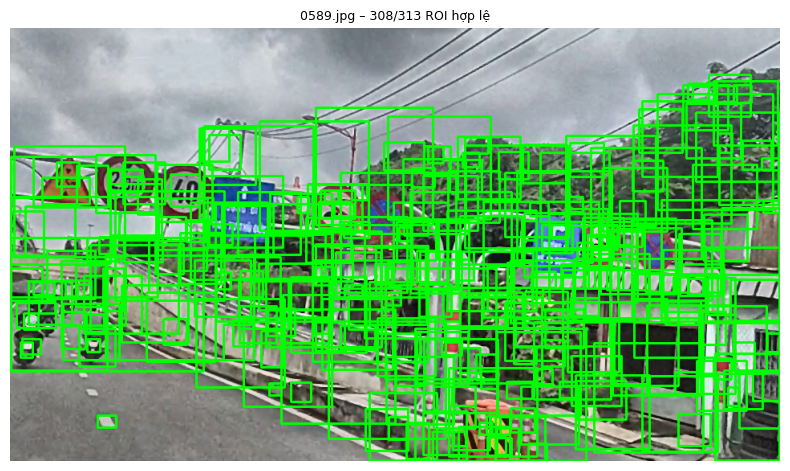

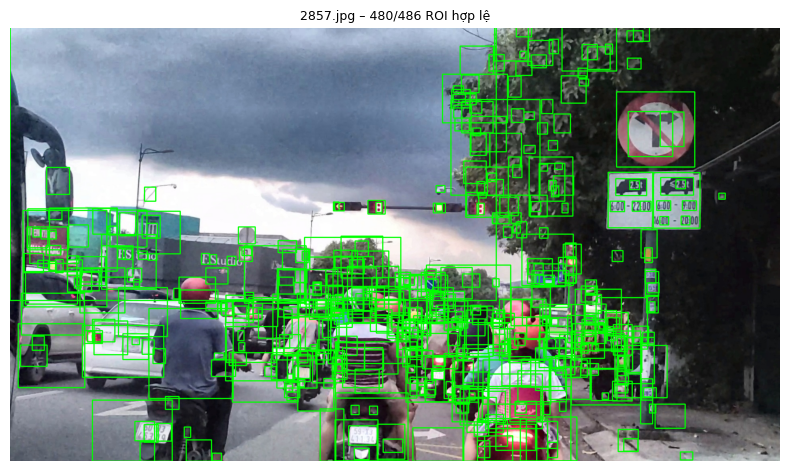

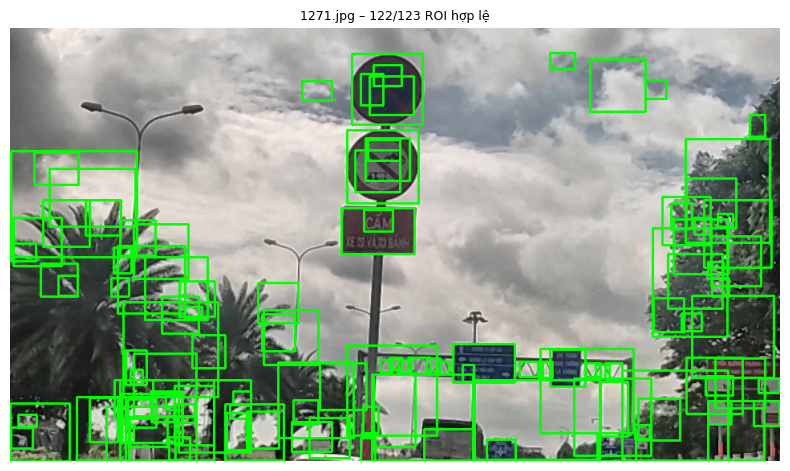

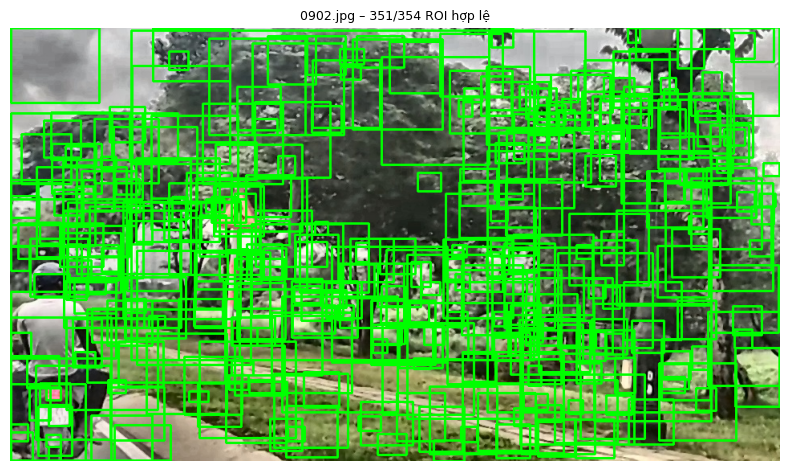

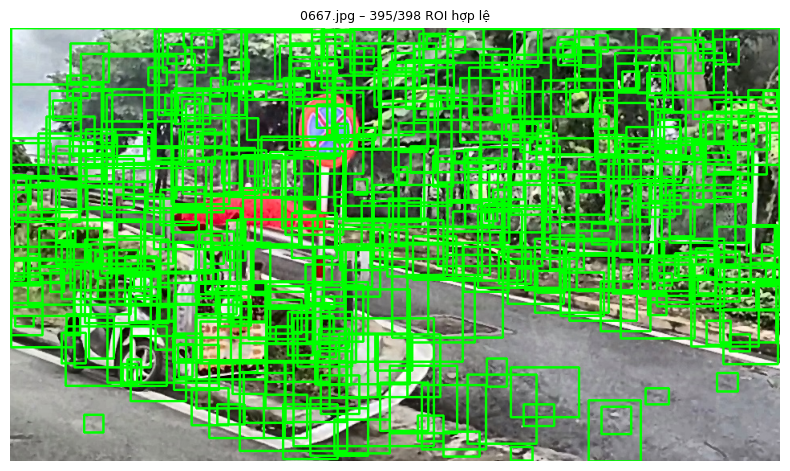

In [18]:
survey_valid_rois = []

for img, items, title in zip(survey_images, survey_candidates, survey_titles):
    valid_rois, _ = extract_rois(img, items, **FINAL_PARAMS)
    survey_valid_rois.append(valid_rois)

    after_vis = draw_rois(img, valid_rois)
    show_images([after_vis], [f"{title} – {len(valid_rois)}/{len(items)} ROI hợp lệ"],
                figsize=(8, 5))


# 7. Resize ROI về kích thước chuẩn cho HOG


Crop minh họa: 1212x680 px (bounding_box=[0, 0, 1212, 680])


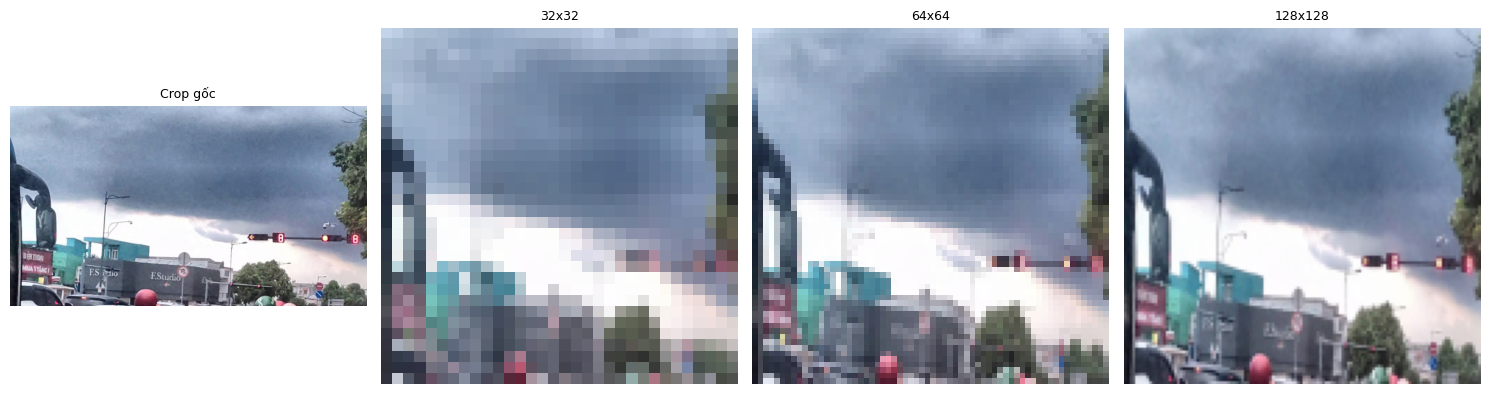

In [19]:
RESIZE_CANDIDATES = [(32, 32), (64, 64), (128, 128)]
all_sample_rois = [r for rois in survey_valid_rois for r in rois]
assert all_sample_rois, "Không có ROI hợp lệ nào trong ảnh mẫu để minh họa resize."

example_roi = max(all_sample_rois, key=lambda r: r["bounding_box"][2] * r["bounding_box"][3])
example_crop = example_roi["crop"]
print(f"Crop minh họa: {example_crop.shape[1]}x{example_crop.shape[0]} px (bounding_box={example_roi['bounding_box']})")

resized_list = [resize_roi(example_crop, size=s) for s in RESIZE_CANDIDATES]
show_images([example_crop] + resized_list,
            ["Crop gốc"] + [f"{s[0]}x{s[1]}" for s in RESIZE_CANDIDATES], figsize=(15, 4))

**Nhận xét :**
- **32×32:** răng cưa mạnh, mất chi tiết viền cong / nét bên trong biển -> HOG kém phân biệt lớp.
- **64×64:** viền mượt, đủ chi tiết cho HOG (9 ori, cell 8×8 → 1764 dim) + color hist; cân bằng chi phí tính toán.
- **128×128:** mượt hơn chút nhưng diminishing return, feature HOG phình to, train SVM chậm hơn rõ.

-> Chọn `resize=(64, 64)`.


In [20]:
SELECTED_RESIZE = (64, 64)
print(f"SELECTED_RESIZE = {SELECTED_RESIZE}")

SELECTED_RESIZE = (64, 64)


# 8. Trích xuất ROI, gán nhãn theo GT & chia Train/val cho Task 6-7

- **Quy tắc gán nhãn:** Một ROI được coi là *positive* nếu IoU với ít nhất 1 GT box >= `IOU_MATCH_THRESHOLD` (0.5 - chặt hơn ngưỡng 0.3 dùng để đo recall/precision phía trên, vì đây là nhãn dùng để huấn luyện SVM nên cần ROI khớp đủ sát với biển thật, tránh dạy mô hình học nhầm từ ROI chỉ trùng một góc nhỏ với biển báo). Nhãn = class GT nếu là positive, `-1` nếu là negative (nền/nhiễu).

- **Cân bằng lớp:** giữ tối đa `NEG_PER_POS = 3` ROI negative cho mỗi 1 ROI positive/ảnh, tránh tập train bị lệch quá nặng về phía "không phải biển báo" (thực tế số contour ứng viên luôn nhiều hơn số biển báo thật rất nhiều lần).

- **Chia train/val theo ẢNH GỐC** (không theo từng ROI riêng lẻ) để các ROI cùng một ảnh không bị chia vào cả 2 tập - tránh rò rỉ dữ liệu (data leakage) làm điểm val ảo cao hơn thực tế.

## 8.1. Thiết lập tham số gán nhãn & chia tập

In [21]:
IOU_MATCH_THRESHOLD = 0.5   
val_RATIO = 0.2             
NEG_PER_POS = 3              

## 8.2. Nạp danh sách train/val cố định từ split_dataset


In [ ]:
from src.utils import compute_iou

all_image_paths_full = list_image_paths(PROCESSED_IMAGE_DIR)
print(f"Tìm thấy {len(all_image_paths_full)} ảnh. Bắt đầu trích xuất + gán nhãn ROI...")

SPLIT_DATASET_DIR = PROJECT_ROOT / "data"/"raw"/"split_dataset"
def load_split_stems(txt_path):
    with open(txt_path, "r", encoding="utf-8") as f:
        lines = [l.strip() for l in f if l.strip()]
    return set(Path(l).stem for l in lines)

val_path = SPLIT_DATASET_DIR / "val_files.txt"
assert val_path.is_file(), (
    "Thiếu val_files.txt. Hãy tách validation từ train theo ảnh nguồn; "
    "không dùng test_files.txt để tuning."
)
train_stems_fixed = load_split_stems(SPLIT_DATASET_DIR / "train_files.txt")
val_stems_fixed   = load_split_stems(val_path)
test_stems_fixed  = load_split_stems(SPLIT_DATASET_DIR / "test_files.txt")

all_image_paths_full = list_image_paths(PROCESSED_IMAGE_DIR)
print(f"Tìm thấy {len(all_image_paths_full)} ảnh đã tiền xử lý (Task 1).")

stems_processed = set(p.stem for p in all_image_paths_full)
for split_name, split_stems in (
    ("train", train_stems_fixed), ("val", val_stems_fixed), ("test", test_stems_fixed)
):
    missing = split_stems - stems_processed
    if missing:
        print(f"[!] {len(missing)} ảnh trong {split_name}_files.txt chưa có sau Task 1")

assert train_stems_fixed.isdisjoint(val_stems_fixed), "Train và val bị giao nhau"
assert train_stems_fixed.isdisjoint(test_stems_fixed), "Train và test bị giao nhau"
assert val_stems_fixed.isdisjoint(test_stems_fixed), "Val và test bị giao nhau"

train_stems = train_stems_fixed & stems_processed
val_stems = val_stems_fixed & stems_processed
test_stems = test_stems_fixed & stems_processed
print(f"Train: {len(train_stems)} | Val: {len(val_stems)} | Test khóa: {len(test_stems)} ảnh")

## 8.3. Trích xuất ROI, gán nhãn theo GT & cân bằng lớp cho từng ảnh

In [ ]:
from tqdm.auto import tqdm
roi_manifest = []

for path in tqdm(all_image_paths_full, desc="Task 4: trích xuất + gán nhãn ROI"):
    stem = path.stem
    if stem in val_stems:
        split = "val"
    elif stem in test_stems:
        split = "test"
    else:
        split = "train"

    items = load_merged_items(stem) 

    img_path = PROCESSED_IMAGE_DIR / f"{stem}.jpg"
    if not img_path.exists():
        img_path = PROCESSED_IMAGE_DIR / f"{stem}.png"
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Bỏ qua (không đọc được ảnh): {stem}")
        continue

    valid_rois, _ = extract_rois(img, items, **FINAL_PARAMS)

    gt_boxes_raw = read_label_boxes(LABEL_DIR / f"{stem}.txt", img.shape)
    gt_boxes = [(g["x1"], g["y1"], g["x2"], g["y2"], g["class"]) for g in gt_boxes_raw]

    pos_items, neg_items = [], []
    for roi in valid_rois:
        x, y, w, h = roi["bounding_box"]
        pred_box = (x, y, x + w, y + h)

        best_iou, best_class = 0.0, -1
        for gx1, gy1, gx2, gy2, gcls in gt_boxes:
            iou = compute_iou(pred_box, (gx1, gy1, gx2, gy2))
            if iou > best_iou:
                best_iou, best_class = iou, gcls

        is_positive = best_iou >= IOU_MATCH_THRESHOLD
        entry = {
            "source_image": stem,
            "split": split,
            "bounding_box": [x, y, w, h],
            "area": w * h,
            "iou_with_gt": round(best_iou, 4),
            "label": best_class if is_positive else -1,
            "crop": roi["crop"],
        }
        (pos_items if is_positive else neg_items).append(entry)

    max_neg = max(len(pos_items) * NEG_PER_POS, 1)
    random.shuffle(neg_items)
    kept_items = pos_items + neg_items[:max_neg]

    for i, entry in enumerate(kept_items):
        resized = resize_roi(entry.pop("crop"), size=SELECTED_RESIZE)
        out_name = f"{stem}_roi{i}.jpg"
        cv2.imwrite(str(ROI_IMG_DIR / out_name), resized)
        entry["roi_file"] = out_name
        roi_manifest.append(entry)

## 8.4. Lưu roi_manifest.json & thống kê số lượng ROI

In [24]:
with open(ROI_META_DIR / "roi_manifest.json", "w", encoding="utf-8") as f:
    json.dump(roi_manifest, f, ensure_ascii=False, indent=2)

n_pos = sum(1 for r in roi_manifest if r["label"] != -1)
n_neg = len(roi_manifest) - n_pos
n_train = sum(1 for r in roi_manifest if r["split"] == "train")
n_val_count = len(roi_manifest) - n_train

print(f"Đã xuất {len(roi_manifest)} ROI -> {ROI_IMG_DIR}")
print(f"  Positive (khớp GT, IoU>={IOU_MATCH_THRESHOLD}): {n_pos}")
print(f"  Negative (nền/nhiễu): {n_neg}")
print(f"  Train: {n_train} | val: {n_val_count} (chia theo ảnh gốc, {len(val_stems)}/{len(stems_processed)} ảnh)")
print(f"Manifest -> {ROI_META_DIR / 'roi_manifest.json'}")

Đã xuất 19359 ROI -> c:\Users\lengo\Downloads\Python\Computer Vision\Project\data\processed\task4_roi\images
  Positive (khớp GT, IoU>=0.5): 4733
  Negative (nền/nhiễu): 14626
  Train: 15458 | val: 3901 (chia theo ảnh gốc, 517/2532 ảnh)
Manifest -> c:\Users\lengo\Downloads\Python\Computer Vision\Project\data\processed\task4_roi\meta\roi_manifest.json


## 8.5. Xem trước một số ROI đã gán nhãn (minh họa)

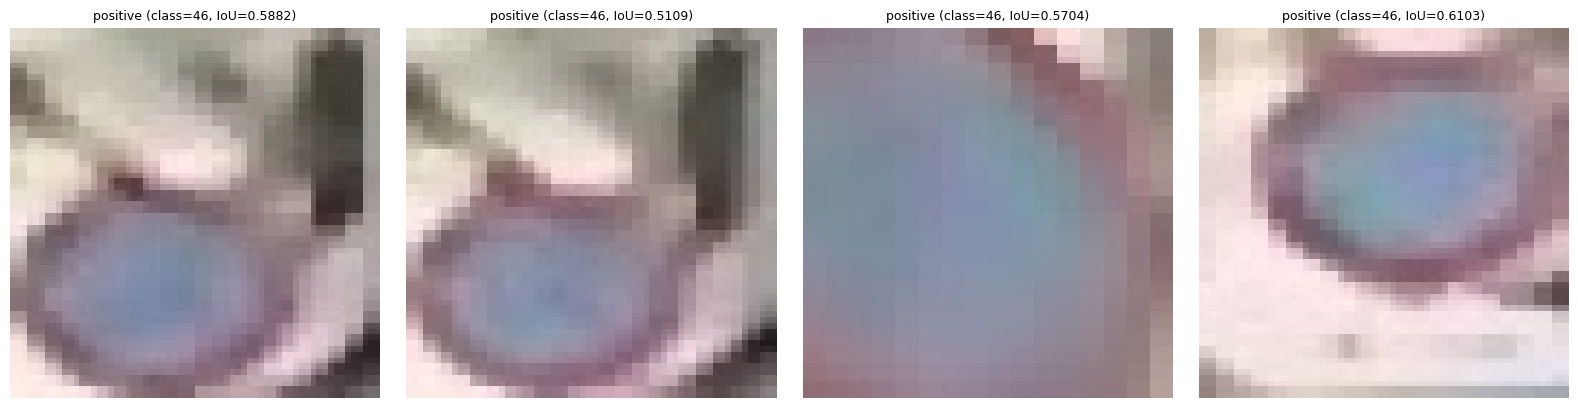

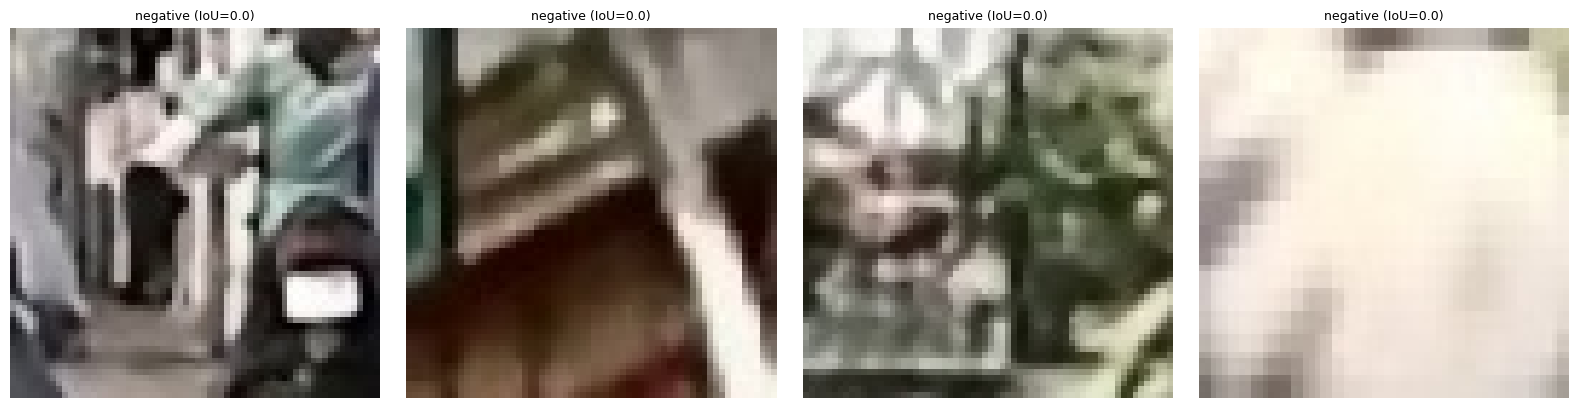

In [25]:
sample_pos = [r for r in roi_manifest if r["label"] != -1][:4]
sample_neg = [r for r in roi_manifest if r["label"] == -1][:4]

if sample_pos:
    imgs = [cv2.imread(str(ROI_IMG_DIR / r["roi_file"])) for r in sample_pos]
    titles = [f'positive (class={r["label"]}, IoU={r["iou_with_gt"]})' for r in sample_pos]
    show_images(imgs, titles, figsize=(16, 4))

if sample_neg:
    imgs = [cv2.imread(str(ROI_IMG_DIR / r["roi_file"])) for r in sample_neg]
    titles = [f'negative (IoU={r["iou_with_gt"]})' for r in sample_neg]
    show_images(imgs, titles, figsize=(16, 4))

# 9. Lưu toàn bộ tham số  vào `config.yaml`

In [26]:
from src.data_loader import save_config

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg.setdefault("task4", {})
cfg["task4"]["nms_iou_threshold"] = NMS_IOU_THRESHOLD
cfg["task4"]["min_w"] = FINAL_PARAMS["min_w"]
cfg["task4"]["min_h"] = FINAL_PARAMS["min_h"]
cfg["task4"]["min_aspect_ratio"] = FINAL_PARAMS["min_aspect_ratio"]
cfg["task4"]["max_aspect_ratio"] = FINAL_PARAMS["max_aspect_ratio"]
cfg["task4"]["resize"] = list(SELECTED_RESIZE)

save_config(cfg, CONFIG_PATH)
print("Đã lưu toàn bộ tham số Task 4 vào config.yaml:")
print(cfg["task4"])

Đã lưu toàn bộ tham số Task 4 vào config.yaml:
{'max_aspect_ratio': 1.9, 'min_aspect_ratio': 0.4, 'min_h': 12, 'min_w': 12, 'nms_iou_threshold': 0.4, 'resize': [64, 64]}
